# 003 - Stage 3: token habits

Stages 1 and 2 separate the **families** (and outliers) well, but not the **sizes**: size accuracy given the correct family is at chance (25.3% in Stage 2). The provenance signals measure how well the family's autoencoder explains an image, and all sizes of a family share that autoencoder, so they cannot tell sizes apart.

**Hypothesis.** Within a family, the variants differ only in the transformer that writes the tokens. If each size has its own "habits" (how varied its tokens are, how often it repeats a token next to itself, how often it uses rare codebook entries), per-image statistics of the tokens can identify the size.

**Recovering the tokens.** The task gives only images, so the tokens are recovered with the Stage 2 inverse decoder:
$$\hat t = Q\big(D^{-1}(x)\big), \qquad x = D\big(Q^{-1}(t)\big),$$
with $Q$ the family's quantizer (RAR: nearest codebook entry on the $16\times16$ grid; VAR: greedy multi-scale residual quantization, Alg. 2, 10 scales $1\times1 \dots 16\times16$). $\hat t = t$ only where $D^{-1}$ inverts $D$ well, so the features are computed on a noisy copy of the true tokens. Token layout and codebooks: RAR $L=256$ tokens from 1,024 codes; VAR $L=680$ tokens from 4,096 codes (`tracer/tokens.py`).

**Data.**
- A **fresh generated set** (`stage3/gen`, `generate_finetune_data.py --seed 1`), not `stage2/gen`, because $D^{-1}$ was trained on most of `stage2/gen` and recovers those tokens better than it would recover new ones.
- Tokens recovered by `scripts/extract_tokens.py` with each family's `stage2/inv/<family>/final.pt`, stored with the generator's true tokens in `stage3/tokens/<family>/gen.npz`.
- Task images (train / val / test) come later, from `stage3/tokens/<family>/task.npz`.

**Pre-registered criteria** (per family, fixed before looking at results):
| check | data | pass if |
|---|---|---|
| Oracle | true generated tokens | 4-way size accuracy $\ge$ 40% (chance 25%); otherwise token habits carry no signal |
| Realistic | recovered tokens, held-out generated images | adjacent-size AUC $\ge$ 0.60 |
| Transfer | task's labelled images | accuracy within 10 points of held-out generated accuracy |

**Rules.** Size classifiers are trained on generated data only; task train / val are for evaluation. RAR and VAR are analysed separately. This notebook only reads cached outputs and runs on the CPU.

Sections: **1. Data checks** (generated set, token recovery, train / holdout split); **2. Oracle: true tokens** (can token habits identify the size at all?); **3. Realistic: recovered tokens** (the same from $\hat t = Q(D^{-1}(x))$); **4. Transfer to task images** (do the generated-data classifiers carry over to the task's labelled images?); **5. End to end** (the Stage 2 rule with the size step replaced where Stage 3 passed); **6. Findings**.

## Setup

In [1]:
import sys, json
from pathlib import Path
REPO = Path("/workspace/iar-model-tracer")
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from tracer.common import CACHE, LABELS, build_index
from tracer.generate import MODELS, VAR_PATCH_NUMS
from tracer.metrics import confusion, family_confusion, report
from tracer.stage1 import KNOWN_FAMILIES, NearestFamilyThreshold
from tracer.tokens import CODEBOOK_SIZE, SEQ_LEN, habit_features, histogram_features, token_frequency

S2 = CACHE / "stage2"  # Stage 2: gen/ (D^-1 training data), inv/<family>/ (D^-1 checkpoints and logs)
S3 = CACHE / "stage3"  # Stage 3: gen/ (fresh generated set), tokens/<family>/{gen,task}.npz
GEN3, TOK = S3 / "gen", S3 / "tokens"
SEED = 0               # train / holdout split, CV folds, bootstrap
HOLDOUT = 0.2
N_BOOT = 2000          # bootstrap resamples for confidence intervals
# VAR: [start, end) of each scale in the 680-token sequence
SCALE_SLICES = dict(zip(VAR_PATCH_NUMS, zip(np.cumsum([0] + [p * p for p in VAR_PATCH_NUMS[:-1]]),
                                            np.cumsum([p * p for p in VAR_PATCH_NUMS]))))

## 1. Data checks

`generate_finetune_data.py --seed 1` sampled every generator with each repo's ImageNet FID settings (as in Stage 2); classes cycle through the 1,000 ImageNet classes in a fixed random order per model. `extract_tokens.py --sources gen` then recovered $\hat t = Q(D^{-1}(x))$ for every sample with the Stage 2 $D^{-1}$.

Checks below:
1. the token files were made from `stage3/gen` with the Stage 2 `final.pt` and no `--limit`; counts per model and class coverage;
2. the fresh set is new: no token sequence also occurs in `stage2/gen`, the data $D^{-1}$ was trained on;
3. token recovery accuracy per model, and for VAR per scale;
4. a fixed train / holdout split of the generated set.

In [2]:
# Check 1: provenance of the token files, then counts and class coverage per model.
gen = {}
for fam in KNOWN_FAMILIES:
    cfg = json.loads((TOK / fam / "gen" / "config.json").read_text())
    assert cfg["inv_ckpt"] == str(S2 / "inv" / fam / "final.pt") and cfg["gen_root"] == str(GEN3), cfg
    assert cfg["limit"] is None, cfg
    gcfg = json.loads((GEN3 / fam / "config.json").read_text())
    print(fam, "generation config:", gcfg, "| token extraction config:", cfg)
    with np.load(TOK / fam / "gen.npz") as z:
        gen[fam] = {k: z[k] for k in z.files}
    d = gen[fam]
    assert d["tokens"].shape == d["true_tokens"].shape == (len(d["label"]), SEQ_LEN[fam])

rows = []
for fam, d in gen.items():
    for lab in MODELS[fam]:
        m = d["label"] == lab
        per_class = np.bincount(d["class"][m], minlength=1000)
        rows.append({"family": fam, "model": lab, "images": int(m.sum()),
                     "distinct classes": int((per_class > 0).sum()),
                     "images per class (min..max)": f"{per_class.min()}..{per_class.max()}",
                     "tokens / image": d["tokens"].shape[1],
                     "true token ids": f'{d["true_tokens"][m].min()}..{d["true_tokens"][m].max()}',
                     "recovered token ids": f'{d["tokens"][m].min()}..{d["tokens"][m].max()}'})
display(pd.DataFrame(rows).set_index(["family", "model"]))

rar generation config: {'family': 'rar', 'shard_size': 512, 'batch_size': 64, 'seed': 1} | token extraction config: {'family': 'rar', 'source': 'gen', 'inv_ckpt': '/workspace/cache/stage2/inv/rar/final.pt', 'shard_size': 512, 'limit': None, 'gen_root': '/workspace/cache/stage3/gen'}
var generation config: {'family': 'var', 'shard_size': 512, 'batch_size': 64, 'seed': 1} | token extraction config: {'family': 'var', 'source': 'gen', 'inv_ckpt': '/workspace/cache/stage2/inv/var/final.pt', 'shard_size': 512, 'limit': None, 'gen_root': '/workspace/cache/stage3/gen'}


images  distinct classes images per class (min..max)  \
family model                                                          
rar    rarb      2560              1000                        2..3   
       rarl      2560              1000                        2..3   
       rarxl     2560              1000                        2..3   
       rarxxl    2560              1000                        2..3   
var    var16     2560              1000                        2..3   
       var20     2560              1000                        2..3   
       var24     2560              1000                        2..3   
       var30     2560              1000                        2..3   

               tokens / image true token ids recovered token ids  
family model                                                      
rar    rarb               256        0..1023             0..1023  
       rarl               256        0..1023             0..1023  
       rarxl              256        0..1023             0..1023  
       rarxxl             256        0..1023             0..1023  
var    var16              680        0..4095             0..4095  
       var20              680        0..4095             0..4095  
       var24              680        0..4095             0..4095  
       var30              680        0..4095             0..4095

In [3]:
# Check 2: no generated token sequence of stage3/gen also occurs in stage2/gen (reads only the tokens of each shard).
for fam, d in gen.items():
    old = set()
    for p in sorted((S2 / "gen" / fam).glob("*/shard_*.npz")):
        with np.load(p) as z:
            old.update(t.tobytes() for t in z["tokens"].astype(np.int16))
    new = [t.tobytes() for t in d["true_tokens"].astype(np.int16)]
    print(f"{fam}: {len(set(new))} distinct sequences in stage3/gen ({len(new)} samples), {len(old)} in stage2/gen, "
          f"shared: {len(set(new) & old)}")

rar: 10240 distinct sequences in stage3/gen (10240 samples), 10240 in stage2/gen, shared: 0


var: 10240 distinct sequences in stage3/gen (10240 samples), 10240 in stage2/gen, shared: 0


### Token recovery accuracy

For image $i$ with true tokens $t_i$ and recovered tokens $\hat t_i$, both of length $L$,
$$\mathrm{acc}_i = \frac{1}{L}\sum_{l=1}^{L} \mathbb 1[\hat t_{i,l} = t_{i,l}],$$
averaged over a model's images. For VAR the same is computed on each scale's slice of the sequence ($p^2$ tokens at scale $p\times p$).

What to expect: about 0.86 for RAR and 0.27 for VAR, the held-out token accuracy at the end of Stage 2 fine-tuning (`log.csv`, shown alongside). VAR is low for a structural reason: its greedy quantizer does not always return $t$ even from the exact features $f_Z = Q^{-1}(t)$ (Stage 2, check 3), and a token changed at one scale changes the residual every later scale quantizes.

Why it matters here: the features will be computed on $\hat t$. If recovery accuracy itself differed between sizes, a classifier on recovered tokens could pick up "how recoverable" an image is rather than token habits, so it should be about equal across sizes.

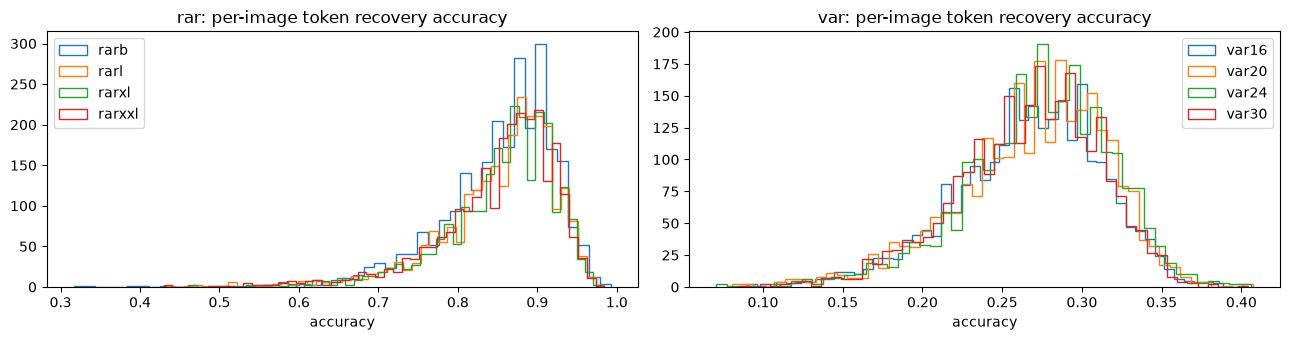

In [4]:
# Recovery accuracy per model (mean, spread over images), next to Stage 2's final held-out token accuracy.
rows = []
for fam, d in gen.items():
    acc = (d["tokens"] == d["true_tokens"]).mean(axis=1)
    d["acc"] = acc
    s2 = pd.read_csv(S2 / "inv" / fam / "log.csv").iloc[-1]["holdout_tok_acc"]
    for lab in MODELS[fam] + ["all"]:
        a = acc if lab == "all" else acc[d["label"] == lab]
        rows.append({"family": fam, "model": lab, "images": len(a), "mean acc": a.mean(),
                     "std": a.std(), "p10": np.percentile(a, 10), "median": np.median(a),
                     "p90": np.percentile(a, 90), "Stage 2 held-out tok_acc": s2})
recovery = pd.DataFrame(rows).set_index(["family", "model"])
display(recovery.style.format("{:.3f}", subset=recovery.columns[1:]))

fig, axs = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, (fam, d) in zip(axs, gen.items()):
    for lab in MODELS[fam]:
        ax.hist(d["acc"][d["label"] == lab], bins=50, histtype="step", label=lab)
    ax.set_title(f"{fam}: per-image token recovery accuracy"); ax.set_xlabel("accuracy"); ax.legend()
plt.tight_layout(); plt.show()

scale (tokens),1x1 (1),2x2 (4),3x3 (9),4x4 (16),5x5 (25),6x6 (36),8x8 (64),10x10 (100),13x13 (169),16x16 (256)
var16,0.737,0.454,0.286,0.205,0.120,0.101,0.162,0.082,0.056,0.538
var20,0.734,0.447,0.267,0.197,0.118,0.098,0.167,0.084,0.058,0.546
var24,0.737,0.431,0.265,0.196,0.113,0.098,0.169,0.085,0.060,0.554
var30,0.730,0.392,0.228,0.175,0.100,0.094,0.171,0.073,0.056,0.548
all,0.734,0.431,0.262,0.193,0.113,0.098,0.167,0.081,0.057,0.547


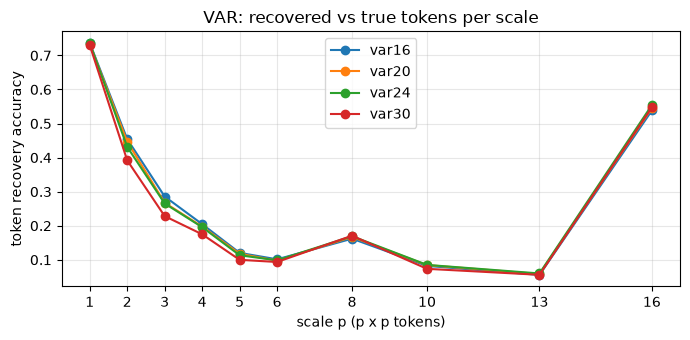

In [5]:
# VAR: recovery accuracy per scale and model. Coarse scales hold few tokens, so they weigh little in the overall mean.
d = gen["var"]
eq = d["tokens"] == d["true_tokens"]
var_scale = pd.DataFrame({f"{p}x{p} ({p * p})": pd.Series(eq[:, a:b].mean(axis=1)).groupby(d["label"]).mean()
                          for p, (a, b) in SCALE_SLICES.items()})
var_scale.loc["all"] = [eq[:, a:b].mean() for a, b in SCALE_SLICES.values()]
var_scale.columns.name = "scale (tokens)"
display(var_scale.style.format("{:.3f}"))

fig, ax = plt.subplots(figsize=(7, 3.5))
for lab in MODELS["var"]:
    ax.plot(VAR_PATCH_NUMS, var_scale.loc[lab].values, "o-", label=lab)
ax.set_xticks(VAR_PATCH_NUMS); ax.set_xlabel("scale p (p x p tokens)"); ax.set_ylabel("token recovery accuracy")
ax.set_title("VAR: recovered vs true tokens per scale"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

### Train / holdout split of the generated set

Per family, 80% train / 20% holdout, stratified by model (`sklearn.model_selection.train_test_split`, `random_state=0`), so each size has the same share in both parts. Size classifiers are fit on train only; the holdout is used for the realistic criterion. The split is saved to `stage3/gen_split.csv` (one row per generated sample, identified by `family`, `label`, `index`) so that later sections and scripts use the same one.

In [6]:
split_rows = []
for fam, d in gen.items():
    pos = np.arange(len(d["label"]))
    tr, ho = train_test_split(pos, test_size=HOLDOUT, stratify=d["label"], random_state=SEED)
    d["split"] = np.full(len(pos), "train", dtype=object)
    d["split"][ho] = "holdout"
    split_rows.append(pd.DataFrame({"family": fam, "label": d["label"], "index": d["index"], "split": d["split"]}))
gen_split = pd.concat(split_rows, ignore_index=True)
assert not gen_split.duplicated(["family", "label", "index"]).any()
gen_split.to_csv(S3 / "gen_split.csv", index=False)
print("wrote", S3 / "gen_split.csv")

rows = []
for fam, d in gen.items():
    for lab in MODELS[fam]:
        for sp in ("train", "holdout"):
            m = (d["label"] == lab) & (d["split"] == sp)
            rows.append({"family": fam, "model": lab, "split": sp, "images": int(m.sum()),
                         "distinct classes": len(np.unique(d["class"][m])), "mean recovery acc": d["acc"][m].mean()})
display(pd.DataFrame(rows).pivot_table(index=["family", "model"], columns="split",
                                       values=["images", "distinct classes", "mean recovery acc"])
        .style.format("{:.0f}").format("{:.3f}", subset=pd.IndexSlice[:, ["mean recovery acc"]]))

wrote /workspace/cache/stage3/gen_split.csv


## 2. Oracle: true tokens

**Question.** Do the sizes of a family write different tokens at all? This uses the generator's **true** tokens $t$, so recovery errors play no part: if the sizes cannot be told apart here, they cannot be told apart from recovered tokens either (pre-registered oracle criterion: 4-way accuracy $\ge$ 40%, chance 25%).

**Features** (`tracer/tokens.py`), per image $i$ with tokens $t_{i,1..L}$ and token histogram $q_{ik} = \frac1L \sum_l \mathbb 1[t_{il} = k]$:
- **histogram** $q_i \in \mathbb R^K$ ($K$ = 1,024 RAR, 4,096 VAR; VAR summed over scales), a sparse matrix;
- **habit features**, a few interpretable summaries of it:
  - entropy $H_i = -\sum_k q_{ik} \log_2 q_{ik}$ and distinct fraction $|\{k : q_{ik} > 0\}| / L$, how varied the tokens are (VAR: also per scale);
  - `same_h` / `same_v`, the fraction of horizontally / vertically adjacent grid positions with the same token, how often a token is repeated next to itself (VAR: scales $\ge 4\times4$);
  - `logfreq_mean` / `logfreq_p10`, the mean and 10th percentile of $\log \hat p_{t_{il}}$ over the image's tokens, how much it uses rare codes. $\hat p_k = (n_k + 1) / (N L + K)$ are the codebook-usage frequencies, counted on the **generated train** tokens only.

**Classifiers**, fit on generated train only (2,048 images per size), one set per family:
- **habit**: `StandardScaler` → multinomial `LogisticRegression` (default $C = 1$);
- **histogram**: `StandardScaler(with_mean=False)` → multinomial `LogisticRegression`, $C$ chosen from a log grid by stratified 5-fold CV accuracy on train, then refit on all of train. The scaler divides each code's column by its train standard deviation and keeps the matrix sparse. Without it the inputs are $O(1/L)$ and the useful range of $C$ would depend on $L$ and $K$.

**Evaluation** on the generated holdout (512 images per size):
- **4-way accuracy**, with a 95% percentile bootstrap interval (2,000 resamples of the holdout images);
- **confusion matrix**, rows = true size;
- **pairwise AUC** for every pair of sizes $(a, b)$, $a$ smaller: on the holdout images of $a$ and $b$, the score is the 4-way model's log-odds $s_i = \log p(b \mid x_i) - \log p(a \mid x_i)$, and $\mathrm{AUC} = P(s_{\text{b image}} > s_{\text{a image}})$. **Adjacent** pairs (neighbouring sizes, the hardest and the ones the realistic criterion uses) and the **extreme** pair (smallest vs largest) are highlighted.

In [7]:
# Oracle features from the TRUE tokens. The frequency table is fit on generated train only.
for fam, d in gen.items():
    tr = d["split"] == "train"
    freq = token_frequency(d["true_tokens"][tr], fam)
    d["oracle_habit"] = habit_features(d["true_tokens"], fam, freq)
    d["oracle_hist"] = histogram_features(d["true_tokens"], fam)
    h = d["oracle_habit"]
    assert np.isfinite(h.values).all()
    print(f"{fam}: habit features {h.shape}, histogram {d['oracle_hist'].shape} "
          f"(mean {d['oracle_hist'].getnnz(axis=1).mean():.0f} non-zero codes per image), "
          f"codes never used in train: {(np.bincount(d['true_tokens'][tr].ravel(), minlength=CODEBOOK_SIZE[fam]) == 0).sum()}")

rar: habit features (10240, 6), histogram (10240, 1024) (mean 193 non-zero codes per image), codes never used in train: 0


var: habit features (10240, 36), histogram (10240, 4096) (mean 615 non-zero codes per image), codes never used in train: 0


In [8]:
C_GRID = np.logspace(-9, 0, 10)  # histogram LR: candidate C values (inverse L2 strength), checked below for edge hits


def fit_habit(X, y):
    # Multinomial is the default for lbfgs with more than two classes.
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X, y)


def fit_hist(X, y):
    cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
    gs = GridSearchCV(make_pipeline(StandardScaler(with_mean=False), LogisticRegression(max_iter=5000)),
                      {"logisticregression__C": C_GRID}, cv=cv, scoring="accuracy", n_jobs=len(C_GRID) * 5)
    return gs.fit(X, y)


def boot_ci(stat, n, rng, n_boot=N_BOOT):
    # 95% percentile interval of stat(idx) over bootstrap resamples idx of range(n).
    vals = [stat(rng.integers(0, n, n)) for _ in range(n_boot)]
    return np.percentile(vals, [2.5, 97.5])


def evaluate(model, X, y, sizes):
    # Holdout accuracy (+ CI), confusion matrix and pairwise AUCs (+ CI) of a fitted 4-way model.
    rng = np.random.default_rng(SEED)
    logp = pd.DataFrame(model.predict_log_proba(X), columns=model.classes_)[sizes]
    pred = logp.columns.values[logp.values.argmax(1)]
    correct = pred == y
    acc_lo, acc_hi = boot_ci(lambda b: correct[b].mean(), len(y), rng)
    cm = pd.DataFrame(confusion_matrix(y, pred, labels=sizes), index=pd.Index(sizes, name="true"),
                      columns=pd.Index(sizes, name="predicted"))
    pairs = []
    for i, a in enumerate(sizes):
        for b in sizes[i + 1:]:
            m = np.isin(y, [a, b])
            yb, s = (y[m] == b), (logp[b] - logp[a]).values[m]
            lo, hi = boot_ci(lambda r: roc_auc_score(yb[r], s[r]), m.sum(), rng, n_boot=1000)
            gap = sizes.index(b) - i
            kind = "adjacent" if gap == 1 else "extreme" if gap == len(sizes) - 1 else ""
            pairs.append({"pair": f"{a} vs {b}", "type": kind, "AUC": roc_auc_score(yb, s), "lo": lo, "hi": hi})
    return {"acc": correct.mean(), "acc_lo": acc_lo, "acc_hi": acc_hi, "cm": cm, "pairs": pd.DataFrame(pairs)}


oracle = {}
for fam, d in gen.items():
    sizes, tr, ho = MODELS[fam], d["split"] == "train", d["split"] == "holdout"
    y = d["label"]
    habit = fit_habit(d["oracle_habit"][tr], y[tr])
    hist = fit_hist(d["oracle_hist"][tr], y[tr])
    best_C = hist.best_params_["logisticregression__C"]
    cv_table = pd.Series(hist.cv_results_["mean_test_score"], index=C_GRID, name="CV accuracy")
    print(f"{fam} histogram LR, 5-fold CV accuracy per C:", cv_table.round(3).to_dict(), f"-> C = {best_C:g}")
    if best_C in (C_GRID[0], C_GRID[-1]):
        print(f"  WARNING: C at the edge of the grid")
    oracle[fam] = {
        "habit": {**evaluate(habit, d["oracle_habit"][ho], y[ho], sizes),
                  "train_acc": habit.score(d["oracle_habit"][tr], y[tr]), "C": 1.0, "cv_acc": np.nan},
        "hist": {**evaluate(hist.best_estimator_, d["oracle_hist"][ho], y[ho], sizes),
                 "train_acc": hist.best_estimator_.score(d["oracle_hist"][tr], y[tr]), "C": best_C,
                 "cv_acc": hist.best_score_},
        "habit_model": habit,
    }

rar histogram LR, 5-fold CV accuracy per C: {1e-09: 0.259, 1e-08: 0.26, 1e-07: 0.26, 1e-06: 0.262, 9.999999999999999e-06: 0.264, 0.0001: 0.256, 0.001: 0.253, 0.01: 0.255, 0.1: 0.251, 1.0: 0.251} -> C = 1e-05


var histogram LR, 5-fold CV accuracy per C: {1e-09: 0.291, 1e-08: 0.291, 1e-07: 0.291, 1e-06: 0.293, 9.999999999999999e-06: 0.295, 0.0001: 0.301, 0.001: 0.29, 0.01: 0.286, 0.1: 0.282, 1.0: 0.281} -> C = 0.0001


### Holdout accuracy and confusion matrices

In [9]:
rows = []
for fam in KNOWN_FAMILIES:
    for clf in ("habit", "hist"):
        r = oracle[fam][clf]
        rows.append({"family": fam, "classifier": clf, "C": r["C"], "train acc (in-sample)": r["train_acc"],
                     "train CV acc": r["cv_acc"], "holdout acc": r["acc"],
                     "95% CI": f"[{r['acc_lo']:.3f}, {r['acc_hi']:.3f}]"})
oracle_acc = pd.DataFrame(rows).set_index(["family", "classifier"])
display(oracle_acc.style.format({"C": "{:g}", "train acc (in-sample)": "{:.3f}", "train CV acc": "{:.3f}",
                                 "holdout acc": "{:.3f}"}, na_rep="-"))

for fam in KNOWN_FAMILIES:
    display(pd.concat({f"{fam} {clf}": oracle[fam][clf]["cm"] for clf in ("habit", "hist")}, axis=1)
            .style.set_caption(f"{fam}: holdout confusion (rows = true, 512 per size)"))

### Pairwise AUC

Adjacent pairs are shaded yellow, the extreme pair blue. 95% bootstrap intervals (1,000 resamples).

In [10]:
def shade(row):
    colour = {"adjacent": "background-color: #fff3c4", "extreme": "background-color: #d6e9ff"}.get(row["type"], "")
    return [colour] * len(row)


for fam in KNOWN_FAMILIES:
    t = pd.concat({clf: oracle[fam][clf]["pairs"].set_index(["pair", "type"])
                   .assign(CI=lambda p: [f"[{a:.3f}, {b:.3f}]" for a, b in zip(p.lo, p.hi)])[["AUC", "CI"]]
                   for clf in ("habit", "hist")}, axis=1).reset_index()
    t.columns = [" ".join(c).strip() if isinstance(c, tuple) else c for c in t.columns]
    display(t.style.apply(shade, axis=1).format({"habit AUC": "{:.3f}", "hist AUC": "{:.3f}"})
            .set_caption(f"{fam}: holdout AUC per pair of sizes (true tokens)").hide(axis="index"))

pair,type,habit AUC,habit CI,hist AUC,hist CI
rarb vs rarl,adjacent,0.527,"[0.489, 0.561]",0.530,"[0.494, 0.567]"
rarb vs rarxl,,0.538,"[0.505, 0.572]",0.511,"[0.473, 0.543]"
rarb vs rarxxl,extreme,0.580,"[0.546, 0.613]",0.529,"[0.495, 0.563]"
rarl vs rarxl,adjacent,0.526,"[0.490, 0.562]",0.507,"[0.470, 0.539]"
rarl vs rarxxl,,0.533,"[0.498, 0.564]",0.534,"[0.500, 0.568]"
rarxl vs rarxxl,adjacent,0.537,"[0.503, 0.571]",0.503,"[0.467, 0.539]"


pair,type,habit AUC,habit CI,hist AUC,hist CI
var16 vs var20,adjacent,0.542,"[0.508, 0.579]",0.574,"[0.540, 0.610]"
var16 vs var24,,0.555,"[0.521, 0.589]",0.551,"[0.515, 0.586]"
var16 vs var30,extreme,0.609,"[0.575, 0.644]",0.607,"[0.572, 0.640]"
var20 vs var24,adjacent,0.516,"[0.480, 0.552]",0.542,"[0.507, 0.578]"
var20 vs var30,,0.569,"[0.533, 0.602]",0.583,"[0.550, 0.618]"
var24 vs var30,adjacent,0.524,"[0.489, 0.559]",0.538,"[0.505, 0.574]"


### Habit features per size

Each habit feature on the **generated train** images (true tokens), one box per size (whiskers 1.5 IQR, outliers hidden). The title gives the single-feature AUC of the extreme pair on train (> 0.5: larger for the largest model).

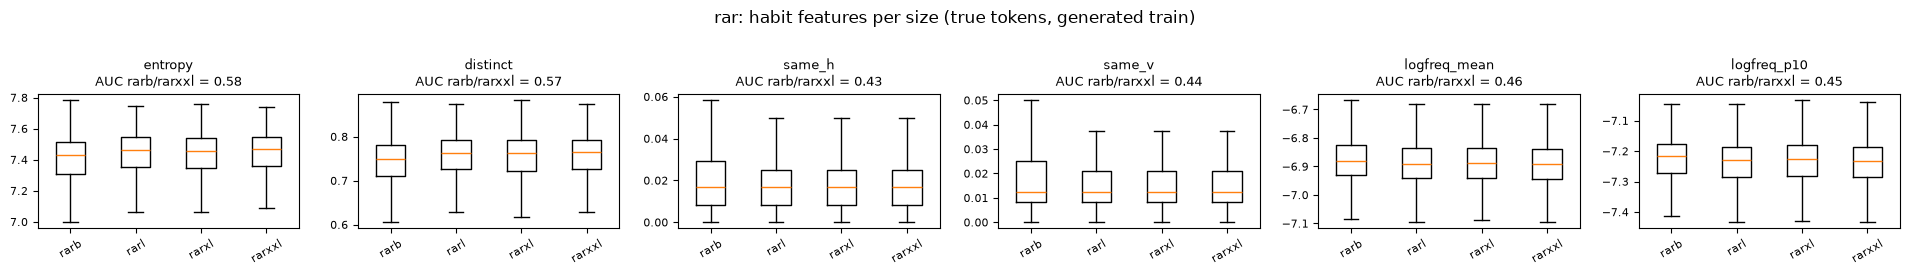

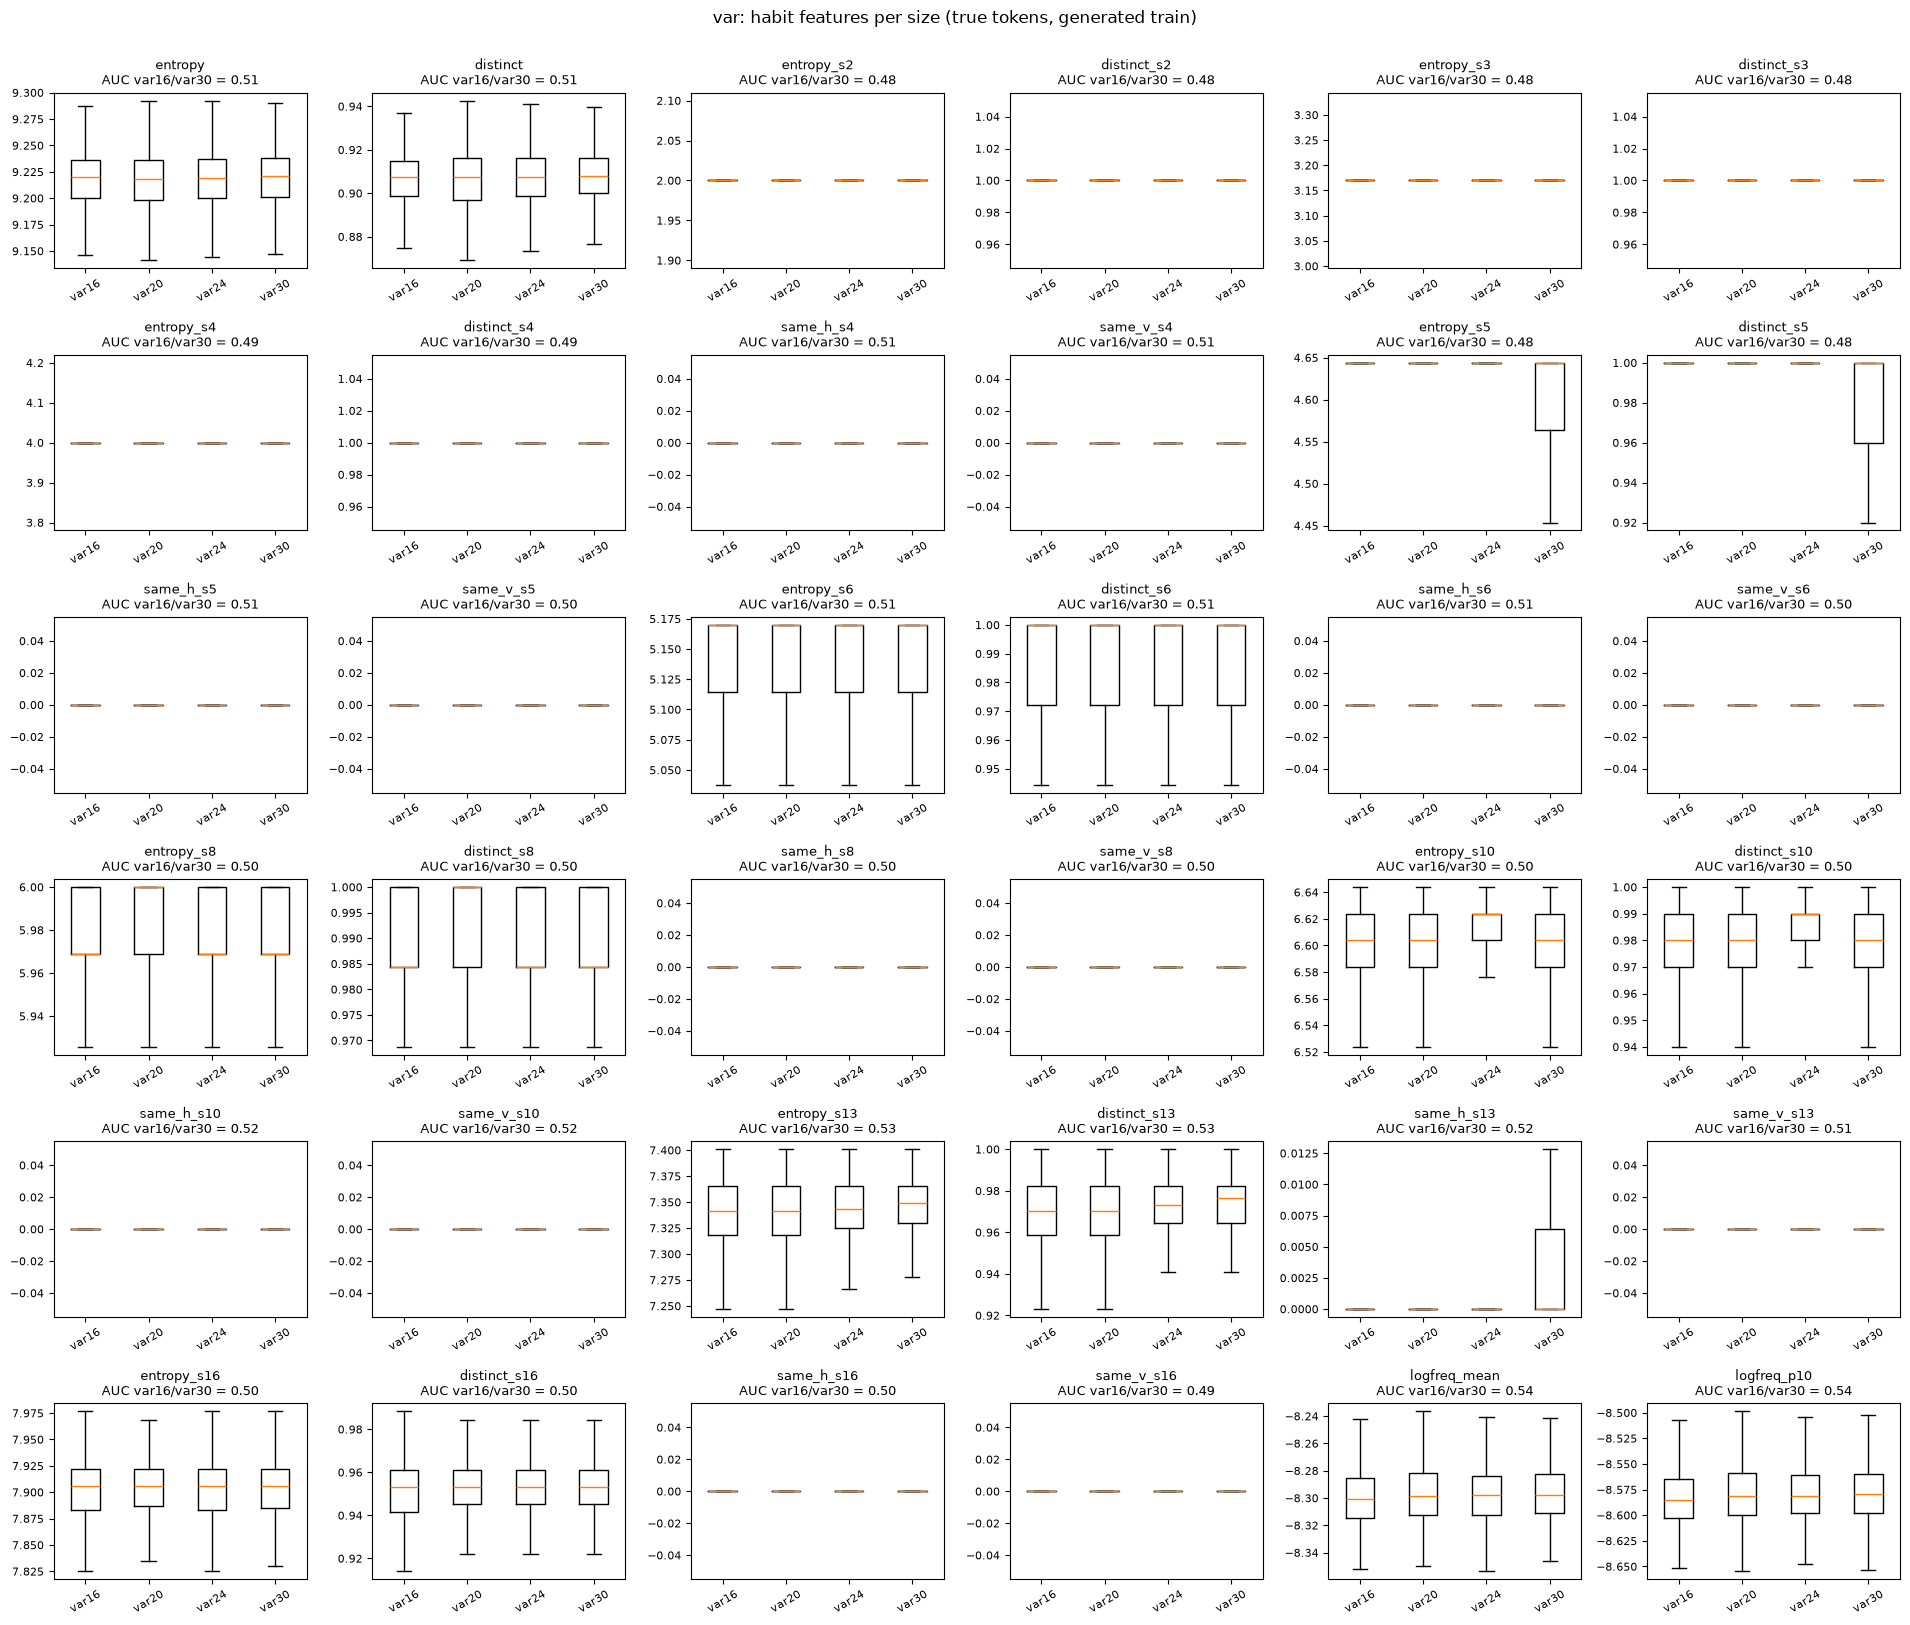

In [11]:
for fam, d in gen.items():
    sizes, tr = MODELS[fam], d["split"] == "train"
    h, y = d["oracle_habit"][tr], d["label"][tr]
    cols = list(h.columns)
    ncol = 6 if len(cols) > 8 else len(cols)
    nrow = int(np.ceil(len(cols) / ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 2.7 * nrow), squeeze=False)
    ext = np.isin(y, [sizes[0], sizes[-1]])
    for ax, c in zip(axs.flat, cols):
        ax.boxplot([h[c].values[y == s] for s in sizes], tick_labels=sizes, showfliers=False)
        auc_ext = roc_auc_score(y[ext] == sizes[-1], h[c].values[ext])
        ax.set_title(f"{c.removeprefix(fam + '_')}\nAUC {sizes[0]}/{sizes[-1]} = {auc_ext:.2f}", fontsize=9)
        ax.tick_params(axis="x", labelsize=8, rotation=30); ax.tick_params(axis="y", labelsize=8)
    for ax in list(axs.flat)[len(cols):]:
        ax.axis("off")
    fig.suptitle(f"{fam}: habit features per size (true tokens, generated train)", y=1.0)
    plt.tight_layout(); plt.show()

### Oracle criterion

Pre-registered: 4-way holdout accuracy $\ge$ 40% on true tokens, per family. Both classifiers are shown. "Pass" uses the point estimate, as pre-registered; the lower end of the 95% interval is shown so a borderline pass is visible.

In [12]:
crit = oracle_acc[["holdout acc", "95% CI"]].copy()
crit["CI low"] = [oracle[f][c]["acc_lo"] for f, c in crit.index]
crit["criterion"] = ">= 0.40"
crit["pass"] = crit["holdout acc"] >= 0.40
crit["pass (CI low >= 0.40)"] = crit["CI low"] >= 0.40
display(crit.style.format({"holdout acc": "{:.3f}", "CI low": "{:.3f}"}))

### Section 2 result

**The oracle criterion fails for both families.** Even with the generator's true tokens, the size is close to chance (25%):

| family | habit LR | histogram LR | criterion |
|---|---|---|---|
| RAR | 27.2% [25.3, 29.2] | 26.2% [24.3, 28.2] (C = 1e-5) | $\ge$ 40%: **fail** |
| VAR | 27.5% [25.7, 29.4] | 29.6% [27.6, 31.6] (C = 1e-4) | $\ge$ 40%: **fail** |

1. **Pairwise AUCs are small.** Adjacent pairs 0.50–0.57 (several intervals include 0.5); extreme pairs 0.58 / 0.53 (RAR habit / histogram) and 0.61 / 0.61 (VAR). There is a weak, roughly monotone size effect, strongest between the smallest and largest model, but far from enough for 4-way attribution.
2. **The classifiers are not just underfit.** The histogram models fit train in-sample (RAR 40%, VAR 72%) but CV accuracy stays at 26% / 30%, and the CV curve is flat or falling as C grows. The confusion matrices show no diagonal, only a lean towards the extreme sizes.
3. **The habit features barely move between sizes.** Per-image token statistics vary much more with the image content than with the size. VAR almost never repeats a token within a scale, so its per-scale entropy and distinct fraction sit at their maximum and `same_h` / `same_v` are 0 for most images; only VAR-d30 repeats noticeably more at scales 5 and 13. RAR-B uses slightly fewer distinct tokens and repeats a bit more often than the larger RAR models.
4. **Consequence for the realistic criterion.** The best oracle adjacent-pair AUC is 0.574 (VAR-d16 vs d20, histogram), already below the 0.60 the realistic criterion requires from recovered tokens, which can only be noisier (Section 1: 85% of RAR and 27% of VAR tokens recovered).

Caveat: only linear models on first-order token statistics (counts, and same-token neighbours). Token co-occurrence beyond direct neighbours, positional statistics, and nonlinear classifiers were not tried.

## 3. Realistic: recovered tokens

Section 2 asked whether the sizes write different tokens. In practice only images are available, so this section repeats Section 2 exactly, with the **recovered** tokens $\hat t = Q(D^{-1}(x))$ in place of the true tokens $t$, for training and for evaluation:
- the frequency table $\hat p_k$ is counted on the recovered tokens of generated train;
- habit and histogram features are computed from $\hat t$;
- the same two classifiers (same $C$ grid and CV folds) are fit on generated train and evaluated on the same holdout images.

Recovery replaces about 15% of RAR tokens and 73% of VAR tokens (Section 1), so the features are noisy copies of the oracle features and the realistic results are expected to be at most as good as the oracle ones.

**One confound to watch.** A classifier on $\hat t$ can also use *how well* the tokens were recovered, not only which tokens the generator wrote. Section 1 showed recovery accuracy is equal across sizes overall, but on VAR's coarse scales it falls slightly with depth (2×2: 0.45 for d16, 0.39 for d30). A realistic result *above* the oracle would point to this.

**Pre-registered criterion:** adjacent-size AUC $\ge$ 0.60 on held-out generated images, per family. It is checked for every adjacent pair; the family passes only if all its adjacent pairs do (the minimum is shown, with the mean for reference).

In [13]:
# Realistic features from the RECOVERED tokens. The frequency table is fit on recovered generated train only.
for fam, d in gen.items():
    tr = d["split"] == "train"
    d["real_freq"] = freq = token_frequency(d["tokens"][tr], fam)
    d["real_habit"] = habit_features(d["tokens"], fam, freq)
    d["real_hist"] = histogram_features(d["tokens"], fam)
    assert np.isfinite(d["real_habit"].values).all()
    assert list(d["real_habit"].columns) == list(d["oracle_habit"].columns)
    print(f"{fam}: habit features {d['real_habit'].shape}, histogram {d['real_hist'].shape} "
          f"(mean {d['real_hist'].getnnz(axis=1).mean():.0f} non-zero codes per image; oracle "
          f"{d['oracle_hist'].getnnz(axis=1).mean():.0f})")

rar: habit features (10240, 6), histogram (10240, 1024) (mean 192 non-zero codes per image; oracle 193)


var: habit features (10240, 36), histogram (10240, 4096) (mean 612 non-zero codes per image; oracle 615)


In [14]:
# Same classifiers, CV and evaluation as Section 2.
realistic = {}
for fam, d in gen.items():
    sizes, tr, ho = MODELS[fam], d["split"] == "train", d["split"] == "holdout"
    y = d["label"]
    habit = fit_habit(d["real_habit"][tr], y[tr])
    hist = fit_hist(d["real_hist"][tr], y[tr])
    best_C = hist.best_params_["logisticregression__C"]
    cv_table = pd.Series(hist.cv_results_["mean_test_score"], index=C_GRID)
    print(f"{fam} histogram LR, 5-fold CV accuracy per C:", {f"{c:g}": round(v, 3) for c, v in cv_table.items()},
          f"-> C = {best_C:g}")
    if best_C in (C_GRID[0], C_GRID[-1]):
        print("  WARNING: C at the edge of the grid")
    realistic[fam] = {
        "habit": {**evaluate(habit, d["real_habit"][ho], y[ho], sizes),
                  "train_acc": habit.score(d["real_habit"][tr], y[tr]), "C": 1.0, "cv_acc": np.nan},
        "hist": {**evaluate(hist.best_estimator_, d["real_hist"][ho], y[ho], sizes),
                 "train_acc": hist.best_estimator_.score(d["real_hist"][tr], y[tr]), "C": best_C,
                 "cv_acc": hist.best_score_},
        "models": {"habit": habit, "hist": hist.best_estimator_},  # reused on task images in Section 4
    }

rar histogram LR, 5-fold CV accuracy per C: {'1e-09': 0.263, '1e-08': 0.264, '1e-07': 0.264, '1e-06': 0.262, '1e-05': 0.26, '0.0001': 0.259, '0.001': 0.26, '0.01': 0.255, '0.1': 0.255, '1': 0.255} -> C = 1e-08


var histogram LR, 5-fold CV accuracy per C: {'1e-09': 0.275, '1e-08': 0.275, '1e-07': 0.275, '1e-06': 0.275, '1e-05': 0.275, '0.0001': 0.266, '0.001': 0.263, '0.01': 0.257, '0.1': 0.256, '1': 0.255} -> C = 1e-05


### Oracle vs realistic: holdout accuracy and confusion matrices

In [15]:
RUNS = {"oracle": oracle, "realistic": realistic}
rows = []
for fam in KNOWN_FAMILIES:
    for clf in ("habit", "hist"):
        row = {"family": fam, "classifier": clf}
        for run, res in RUNS.items():
            r = res[fam][clf]
            row.update({(run, "C"): r["C"], (run, "train CV acc"): r["cv_acc"], (run, "holdout acc"): r["acc"],
                        (run, "95% CI"): f"[{r['acc_lo']:.3f}, {r['acc_hi']:.3f}]"})
        rows.append(row)
acc_cmp = pd.DataFrame(rows).set_index(["family", "classifier"])
acc_cmp.columns = pd.MultiIndex.from_tuples(acc_cmp.columns)
acc_cmp[("realistic - oracle", "holdout acc")] = acc_cmp[("realistic", "holdout acc")] - acc_cmp[("oracle", "holdout acc")]
display(acc_cmp.style.format("{:.3f}", subset=[c for c in acc_cmp.columns if c[1] in ("train CV acc", "holdout acc")],
                             na_rep="-")
        .format("{:g}", subset=[c for c in acc_cmp.columns if c[1] == "C"]))

for fam in KNOWN_FAMILIES:
    display(pd.concat({f"{run} {clf}": RUNS[run][fam][clf]["cm"] for clf in ("habit", "hist") for run in RUNS}, axis=1)
            .style.set_caption(f"{fam}: holdout confusion (rows = true, 512 per size)"))

### Oracle vs realistic: pairwise AUC

Same definition and shading as Section 2 (adjacent yellow, extreme blue; 95% bootstrap intervals).

In [16]:
for fam in KNOWN_FAMILIES:
    parts = {}
    for clf in ("habit", "hist"):
        for run in RUNS:
            p = RUNS[run][fam][clf]["pairs"].set_index(["pair", "type"])
            parts[f"{clf} {run}"] = p.assign(CI=[f"[{a:.3f}, {b:.3f}]" for a, b in zip(p.lo, p.hi)])[["AUC", "CI"]]
    t = pd.concat(parts, axis=1).reset_index()
    t.columns = [" ".join(c).strip() if isinstance(c, tuple) else c for c in t.columns]
    display(t.style.apply(shade, axis=1).format({c: "{:.3f}" for c in t.columns if c.endswith("AUC")})
            .set_caption(f"{fam}: holdout AUC per pair of sizes, oracle (true tokens) vs realistic (recovered)")
            .hide(axis="index"))

pair,type,habit oracle AUC,habit oracle CI,habit realistic AUC,habit realistic CI,hist oracle AUC,hist oracle CI,hist realistic AUC,hist realistic CI
rarb vs rarl,adjacent,0.527,"[0.489, 0.561]",0.528,"[0.488, 0.563]",0.530,"[0.494, 0.567]",0.517,"[0.481, 0.552]"
rarb vs rarxl,,0.538,"[0.505, 0.572]",0.532,"[0.498, 0.567]",0.511,"[0.473, 0.543]",0.513,"[0.477, 0.547]"
rarb vs rarxxl,extreme,0.580,"[0.546, 0.613]",0.560,"[0.527, 0.595]",0.529,"[0.495, 0.563]",0.532,"[0.497, 0.564]"
rarl vs rarxl,adjacent,0.526,"[0.490, 0.562]",0.526,"[0.491, 0.561]",0.507,"[0.470, 0.539]",0.501,"[0.464, 0.534]"
rarl vs rarxxl,,0.533,"[0.498, 0.564]",0.508,"[0.471, 0.542]",0.534,"[0.500, 0.568]",0.524,"[0.487, 0.560]"
rarxl vs rarxxl,adjacent,0.537,"[0.503, 0.571]",0.517,"[0.481, 0.551]",0.503,"[0.467, 0.539]",0.492,"[0.456, 0.527]"


pair,type,habit oracle AUC,habit oracle CI,habit realistic AUC,habit realistic CI,hist oracle AUC,hist oracle CI,hist realistic AUC,hist realistic CI
var16 vs var20,adjacent,0.542,"[0.508, 0.579]",0.502,"[0.468, 0.536]",0.574,"[0.540, 0.610]",0.523,"[0.488, 0.556]"
var16 vs var24,,0.555,"[0.521, 0.589]",0.545,"[0.510, 0.580]",0.551,"[0.515, 0.586]",0.536,"[0.503, 0.570]"
var16 vs var30,extreme,0.609,"[0.575, 0.644]",0.537,"[0.500, 0.569]",0.607,"[0.572, 0.640]",0.540,"[0.504, 0.572]"
var20 vs var24,adjacent,0.516,"[0.480, 0.552]",0.520,"[0.485, 0.557]",0.542,"[0.507, 0.578]",0.531,"[0.496, 0.565]"
var20 vs var30,,0.569,"[0.533, 0.602]",0.517,"[0.485, 0.551]",0.583,"[0.550, 0.618]",0.523,"[0.491, 0.561]"
var24 vs var30,adjacent,0.524,"[0.489, 0.559]",0.516,"[0.484, 0.552]",0.538,"[0.505, 0.574]",0.494,"[0.461, 0.531]"


### Habit features per size (recovered tokens)

As in Section 2, on generated train, now from the recovered tokens.

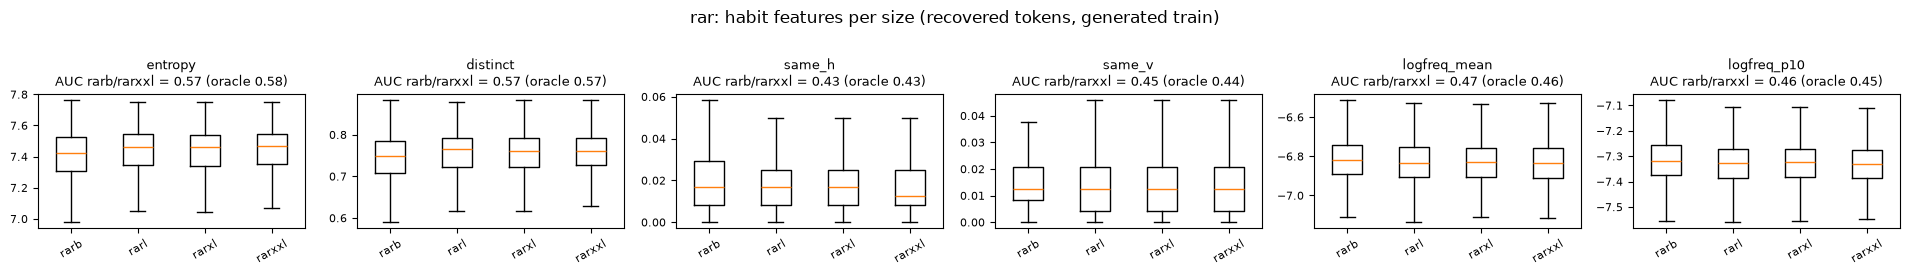

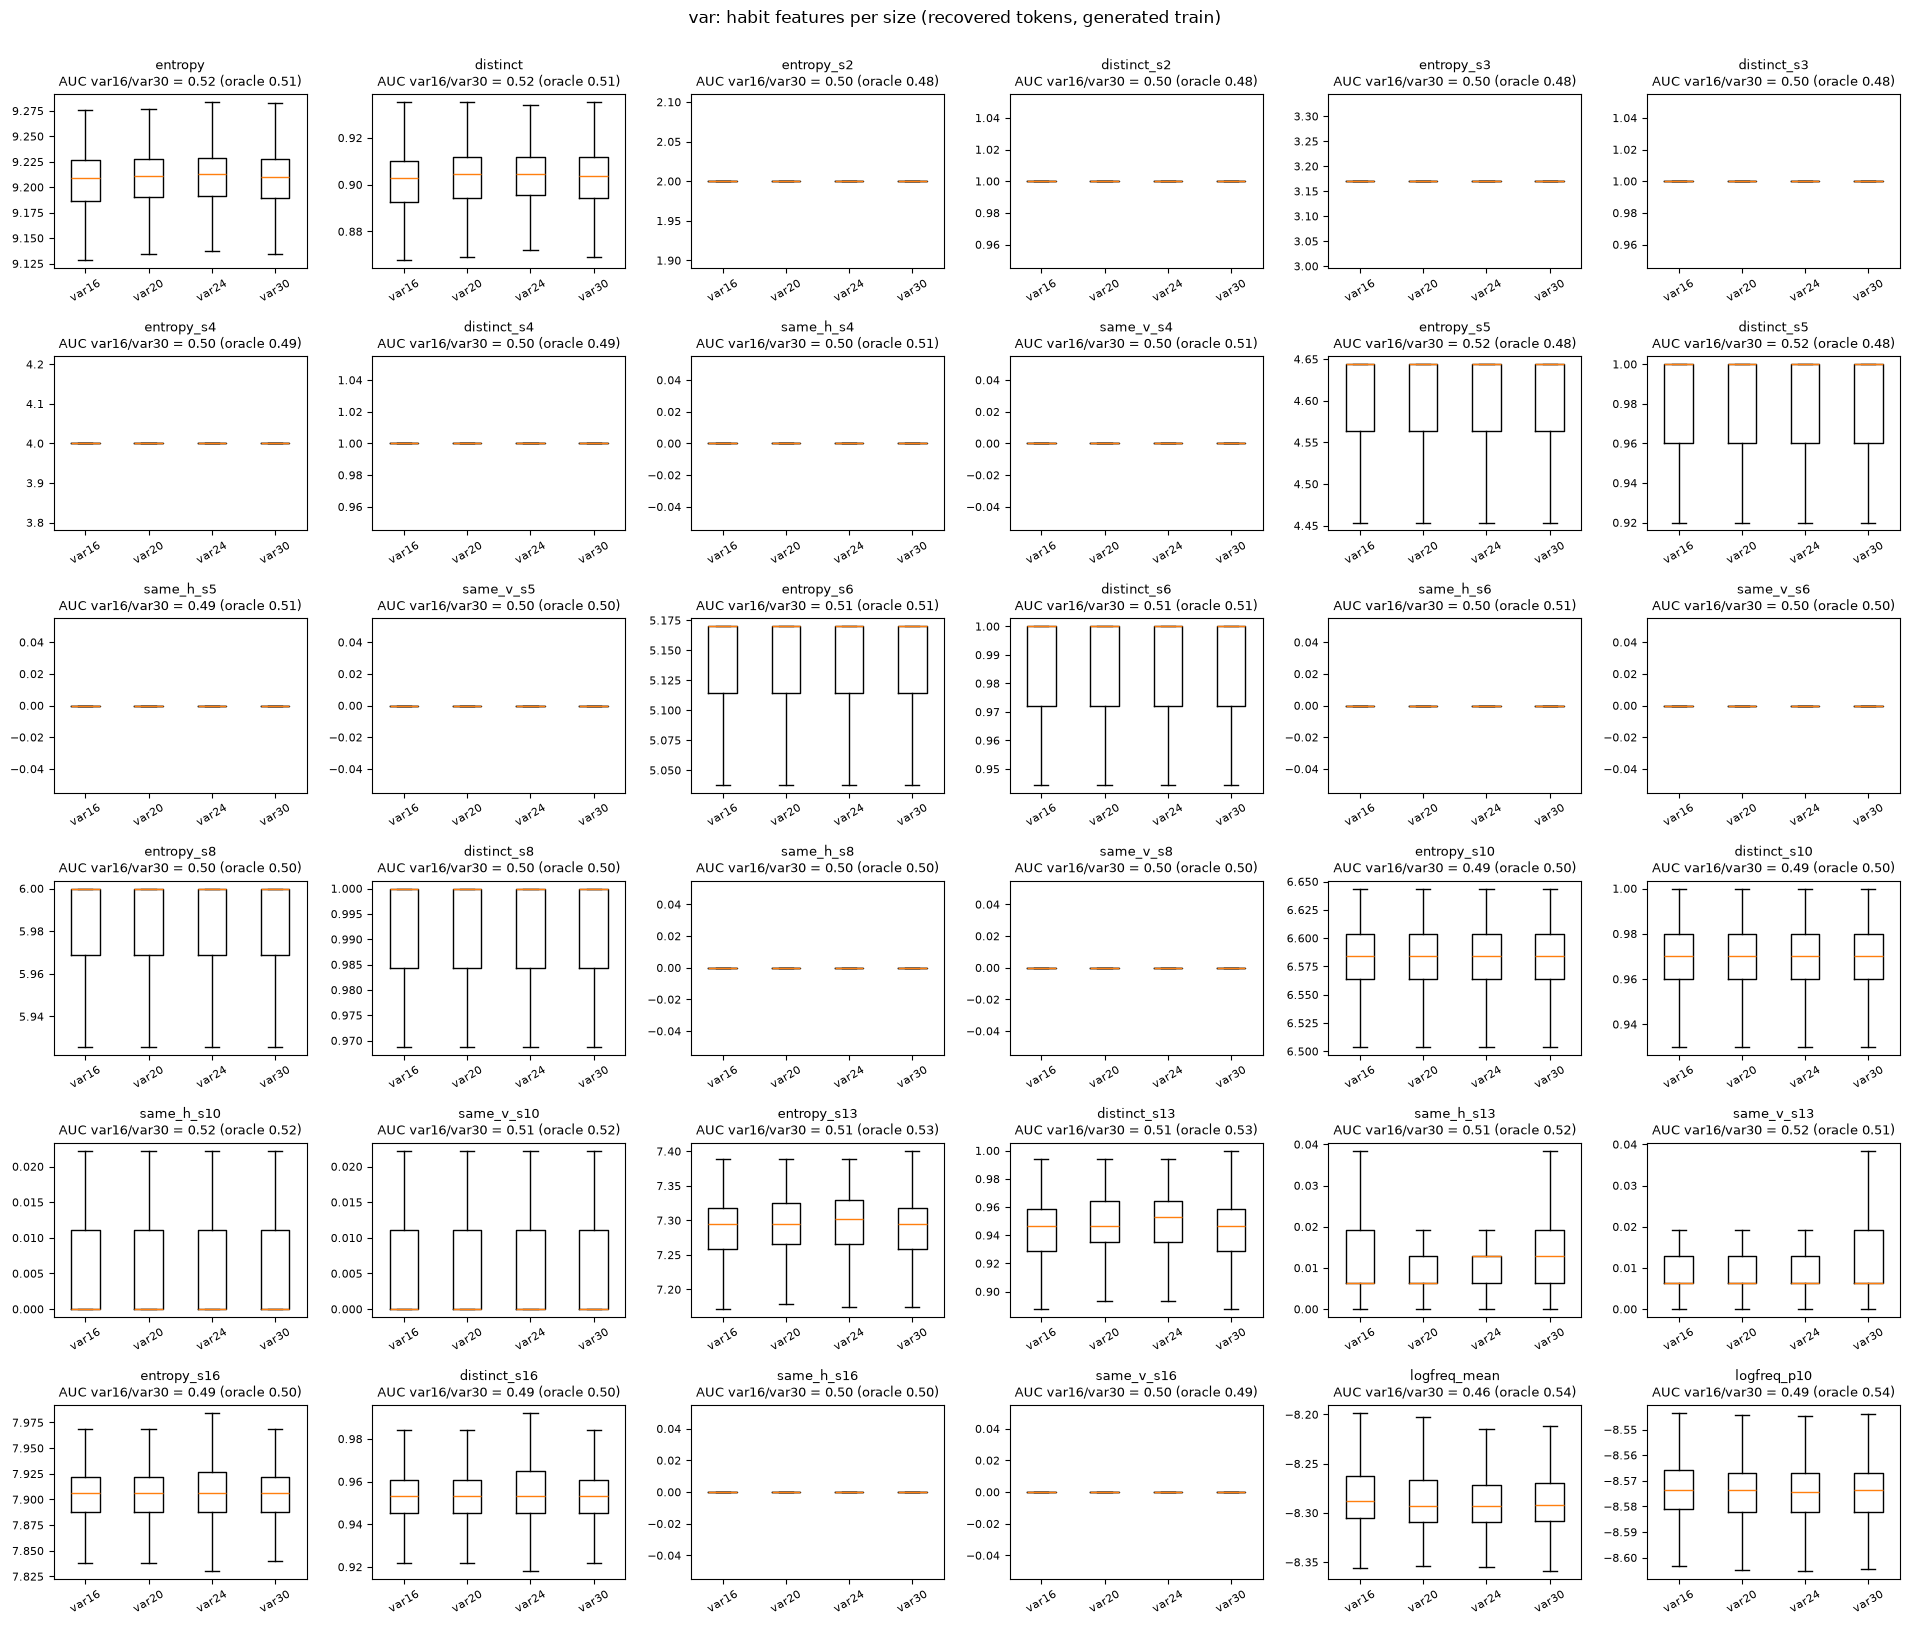

In [17]:
for fam, d in gen.items():
    sizes, tr = MODELS[fam], d["split"] == "train"
    h, y = d["real_habit"][tr], d["label"][tr]
    cols = list(h.columns)
    ncol = 6 if len(cols) > 8 else len(cols)
    nrow = int(np.ceil(len(cols) / ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 2.7 * nrow), squeeze=False)
    ext = np.isin(y, [sizes[0], sizes[-1]])
    for ax, c in zip(axs.flat, cols):
        ax.boxplot([h[c].values[y == s] for s in sizes], tick_labels=sizes, showfliers=False)
        auc_ext = roc_auc_score(y[ext] == sizes[-1], h[c].values[ext])
        auc_or = roc_auc_score(y[ext] == sizes[-1], d["oracle_habit"][tr][c].values[ext])
        ax.set_title(f"{c.removeprefix(fam + '_')}\nAUC {sizes[0]}/{sizes[-1]} = {auc_ext:.2f} (oracle {auc_or:.2f})",
                     fontsize=9)
        ax.tick_params(axis="x", labelsize=8, rotation=30); ax.tick_params(axis="y", labelsize=8)
    for ax in list(axs.flat)[len(cols):]:
        ax.axis("off")
    fig.suptitle(f"{fam}: habit features per size (recovered tokens, generated train)", y=1.0)
    plt.tight_layout(); plt.show()

### Realistic criterion

Pre-registered: adjacent-size AUC $\ge$ 0.60 on held-out generated images (recovered tokens), per family. The family passes if every adjacent pair does. The oracle values are shown for reference only; the criterion applies to the realistic run.

In [18]:
rows = []
for fam in KNOWN_FAMILIES:
    for clf in ("habit", "hist"):
        adj = {run: RUNS[run][fam][clf]["pairs"].query("type == 'adjacent'") for run in RUNS}
        r = adj["realistic"]
        rows.append({"family": fam, "classifier": clf,
                     "adjacent AUCs (realistic)": ", ".join(f"{a:.3f}" for a in r.AUC),
                     "min": r.AUC.min(), "mean": r.AUC.mean(), "min CI low": r.lo.min(),
                     "oracle min": adj["oracle"].AUC.min(), "oracle mean": adj["oracle"].AUC.mean(),
                     "criterion": ">= 0.60", "pass (all adjacent >= 0.60)": bool((r.AUC >= 0.60).all())})
crit3 = pd.DataFrame(rows).set_index(["family", "classifier"])
display(crit3.style.format({c: "{:.3f}" for c in ["min", "mean", "min CI low", "oracle min", "oracle mean"]}))

### Section 3 result

**The realistic criterion fails for both families.** No adjacent pair reaches AUC 0.60 with either classifier; every adjacent interval includes 0.5:

| family | classifier | adjacent AUCs (realistic) | oracle adjacent AUCs | 4-way holdout acc, realistic (oracle) |
|---|---|---|---|---|
| RAR | habit | 0.528, 0.526, 0.517 | 0.527, 0.526, 0.537 | 26.2% (27.2%) |
| RAR | histogram | 0.517, 0.501, 0.492 | 0.530, 0.507, 0.503 | 25.5% (26.2%) |
| VAR | habit | 0.502, 0.520, 0.516 | 0.542, 0.516, 0.524 | 27.0% (27.5%) |
| VAR | histogram | 0.523, 0.531, 0.494 | 0.574, 0.542, 0.538 | 26.2% (29.6%) |

1. **Recovery removes most of the little signal there was.** Every realistic accuracy is at or below its oracle value. The extreme-pair AUCs drop from 0.58 / 0.53 to 0.56 / 0.53 for RAR (habit / histogram), and from 0.61 / 0.61 to 0.54 / 0.54 for VAR.
2. **RAR's features barely change** (85% of tokens recovered): the habit boxplots and single-feature AUCs match the oracle to within 0.01–0.02. The size simply is not in these features, with or without recovery.
3. **VAR's features change shape** (27% of tokens recovered). VAR-d30's slightly lower entropy at 5×5 and extra repeats at 13×13 (Section 2) vanish, and recovery adds same-token repeats at 10×10 and 13×13 for every size. The size signal the histogram classifier found in the true tokens (adjacent 0.54–0.57) falls to 0.49–0.53.
4. **No sign of the recoverability confound.** The realistic results are not above the oracle ones, so differences in recovery accuracy between sizes are not being exploited.
5. **Histogram C** is chosen at the strong-regularisation end (RAR 1e-8, VAR 1e-5), where the CV accuracy curve is flat at 26–28%. The classifier finds nothing it can use beyond the class priors.

## 4. Transfer to task images

**Question.** The classifiers were trained on our own generated images, sampled with each repo's ImageNet FID settings. The task's images were generated with unknown settings. If those differ (guidance scale, temperature, top-k / top-p), token statistics can shift, and a classifier that works on our holdout can fail on the task.

**Setup.**
- Task images: the in-distribution **train** (100 per size) and **val** (50 per size) images of each family. The **true family is given**, so this measures the size step alone; outliers are not used.
- Tokens: recovered with the same Stage 2 $D^{-1}$ (`extract_tokens.py --sources task`, `stage3/tokens/<family>/task.npz`).
- Features: as in Section 3, with the **same frequency table** (recovered generated train). Nothing is refit on task images.
- **Main result:** the Section 3 realistic classifiers, applied unchanged. Accuracy with 95% bootstrap intervals and confusion matrices, next to the Section 3 holdout accuracy.

**Pre-registered transfer criterion:** accuracy on the task's labelled images within 10 points of the held-out generated accuracy. "Task's labelled images" is taken as train and val together (150 per size); train and val are also shown separately. A larger drop would mean the task used different sampling settings.

**Separate comparison (not the pre-registered test).** The same two classifiers trained on task **train** (frequency table and histogram $C$ from task train only, 5-fold CV), evaluated on task **val**. This asks whether the task's own images contain a size signal that our generated data misses. It has only 100 training images per size and 50 val images per size, so its intervals are wide (about ±7 points).

In [19]:
# Task tokens: check provenance and row order, then keep the in-distribution train / val images of each family.
idx = build_index()
task = {}
for fam in KNOWN_FAMILIES:
    cfg = json.loads((TOK / fam / "task" / "config.json").read_text())
    assert cfg["inv_ckpt"] == str(S2 / "inv" / fam / "final.pt") and cfg["limit"] is None, cfg
    with np.load(TOK / fam / "task.npz") as z:
        t = {k: z[k] for k in z.files}
    assert (t["key"] == idx.key.values).all(), "task tokens are not in build_index() order"
    m = np.isin(t["split"], ["train", "val"]) & (t["family"] == fam)
    task[fam] = {k: v[m] for k, v in t.items()}
    task[fam]["habit"] = habit_features(task[fam]["tokens"], fam, gen[fam]["real_freq"])  # generated-train table
    task[fam]["hist"] = histogram_features(task[fam]["tokens"], fam)
    print(fam, "task images:", pd.crosstab(task[fam]["label"], task[fam]["split"]).to_dict())

rar task images: {'train': {'rarb': 100, 'rarl': 100, 'rarxl': 100, 'rarxxl': 100}, 'val': {'rarb': 50, 'rarl': 50, 'rarxl': 50, 'rarxxl': 50}}
var task images: {'train': {'var16': 100, 'var20': 100, 'var24': 100, 'var30': 100}, 'val': {'var16': 50, 'var20': 50, 'var24': 50, 'var30': 50}}


In [20]:
# Main result: Section 3 realistic classifiers (generated train only) on task train / val / train+val.
rows, cms = [], {}
for fam in KNOWN_FAMILIES:
    sizes, tk = MODELS[fam], task[fam]
    for clf in ("habit", "hist"):
        model = realistic[fam]["models"][clf]
        X = tk["habit"] if clf == "habit" else tk["hist"]
        hold = realistic[fam][clf]
        row = {"family": fam, "classifier": clf,
               "gen holdout acc": hold["acc"], "gen holdout CI": f"[{hold['acc_lo']:.3f}, {hold['acc_hi']:.3f}]"}
        for part, m in [("task train", tk["split"] == "train"), ("task val", tk["split"] == "val"),
                        ("task train+val", np.ones(len(tk["split"]), bool))]:
            r = evaluate(model, X[m], tk["label"][m], sizes)
            row[f"{part} acc"], row[f"{part} CI"] = r["acc"], f"[{r['acc_lo']:.3f}, {r['acc_hi']:.3f}]"
            if part == "task train+val":
                cms[(fam, clf)] = r["cm"]
                row["adjacent AUCs (train+val)"] = ", ".join(f"{a:.3f}" for a in r["pairs"].query("type == 'adjacent'").AUC)
        row["gap (holdout - task train+val)"] = row["gen holdout acc"] - row["task train+val acc"]
        rows.append(row)
transfer = pd.DataFrame(rows).set_index(["family", "classifier"])
display(transfer.style.format({c: "{:.3f}" for c in transfer.columns if c.endswith("acc") or c.startswith("gap")}))

for fam in KNOWN_FAMILIES:
    display(pd.concat({f"{fam} {clf}": cms[(fam, clf)] for clf in ("habit", "hist")}, axis=1)
            .style.set_caption(f"{fam}: task train+val confusion, generated-trained classifiers "
                               f"(rows = true, 150 per size)"))

### Separate comparison: trained on task train, evaluated on task val

Not part of the pre-registered evaluation. Same features and classifiers, but everything (frequency table, scaler, logistic regression, histogram $C$) is fit on the task's train images only.

In [21]:
rows, cms_tt = [], {}
for fam in KNOWN_FAMILIES:
    sizes, tk = MODELS[fam], task[fam]
    tr, va = tk["split"] == "train", tk["split"] == "val"
    y = tk["label"]
    freq_task = token_frequency(tk["tokens"][tr], fam)
    habit_X = habit_features(tk["tokens"], fam, freq_task)
    hist_X = tk["hist"]
    habit = fit_habit(habit_X[tr], y[tr])
    hist = fit_hist(hist_X[tr], y[tr])
    best_C = hist.best_params_["logisticregression__C"]
    print(f"{fam} histogram LR on task train, 5-fold CV accuracy per C:",
          {f"{c:g}": round(float(v), 3) for c, v in zip(C_GRID, hist.cv_results_["mean_test_score"])}, f"-> C = {best_C:g}")
    if best_C in (C_GRID[0], C_GRID[-1]):
        print("  WARNING: C at the edge of the grid")
    for clf, model, X in [("habit", habit, habit_X), ("hist", hist.best_estimator_, hist_X)]:
        r = evaluate(model, X[va], y[va], sizes)
        cms_tt[(fam, clf)] = r["cm"]
        rows.append({"family": fam, "classifier": clf, "C": 1.0 if clf == "habit" else best_C,
                     "task train acc (in-sample)": model.score(X[tr], y[tr]),
                     "task val acc": r["acc"], "task val CI": f"[{r['acc_lo']:.3f}, {r['acc_hi']:.3f}]",
                     "adjacent AUCs (val)": ", ".join(f"{a:.3f}" for a in r["pairs"].query("type == 'adjacent'").AUC),
                     "generated-trained, task val acc": transfer.loc[(fam, clf), "task val acc"]})
task_trained = pd.DataFrame(rows).set_index(["family", "classifier"])
display(task_trained.style.format({"C": "{:g}", "task train acc (in-sample)": "{:.3f}", "task val acc": "{:.3f}",
                                   "generated-trained, task val acc": "{:.3f}"})
        .set_caption("COMPARISON ONLY: classifiers trained on task train, evaluated on task val (50 per size)"))
for fam in KNOWN_FAMILIES:
    display(pd.concat({f"{fam} {clf}": cms_tt[(fam, clf)] for clf in ("habit", "hist")}, axis=1)
            .style.set_caption(f"COMPARISON ONLY, {fam}: task val confusion, task-trained classifiers"))

rar histogram LR on task train, 5-fold CV accuracy per C: {'1e-09': 0.235, '1e-08': 0.235, '1e-07': 0.235, '1e-06': 0.235, '1e-05': 0.233, '0.0001': 0.24, '0.001': 0.247, '0.01': 0.253, '0.1': 0.258, '1': 0.253} -> C = 0.1


var histogram LR on task train, 5-fold CV accuracy per C: {'1e-09': 0.215, '1e-08': 0.215, '1e-07': 0.215, '1e-06': 0.215, '1e-05': 0.208, '0.0001': 0.215, '0.001': 0.202, '0.01': 0.198, '0.1': 0.197, '1': 0.205} -> C = 1e-09


### Transfer criterion

Pre-registered: task accuracy (train + val) within 10 points of the held-out generated accuracy, per family. The criterion only measures a *drop*; whether that drop is meaningful depends on how far above chance (25%) the holdout accuracy was to begin with, so that is shown too.

In [22]:
crit4 = transfer[["gen holdout acc", "task train+val acc", "task train+val CI", "gap (holdout - task train+val)"]].copy()
crit4["holdout above chance (pts)"] = 100 * (crit4["gen holdout acc"] - 0.25)
crit4["criterion"] = "|gap| <= 10 pts"
crit4["pass"] = crit4["gap (holdout - task train+val)"].abs() <= 0.10
display(crit4.style.format({"gen holdout acc": "{:.3f}", "task train+val acc": "{:.3f}",
                            "gap (holdout - task train+val)": "{:+.3f}", "holdout above chance (pts)": "{:.1f}"}))

### Section 4 result

**The transfer criterion passes, but only because there is nothing to transfer.** The Section 3 classifiers score the same on the task's labelled images as on our holdout, and both are at chance:

| family | classifier | generated holdout | task train + val (600 images) | gap | criterion (\|gap\| $\le$ 10 pts) |
|---|---|---|---|---|---|
| RAR | habit | 26.2% | 28.5% [25.2, 32.0] | −2.3 | pass |
| RAR | histogram | 25.5% | 26.2% [22.7, 29.7] | −0.6 | pass |
| VAR | habit | 27.0% | 25.3% [21.8, 28.8] | +1.6 | pass |
| VAR | histogram | 26.2% | 24.3% [20.8, 27.8] | +1.8 | pass |

Every task interval contains 25%, the confusion matrices have no diagonal, and the task adjacent AUCs are 0.44–0.55.

**Comparison only (trained on task train, evaluated on task val):** RAR 30.5% / 27.0%, VAR 28.0% / 25.0% (habit / histogram), every interval containing 25%. The models fit task train in-sample (histogram 100%, VAR habit 42%) but do not generalise to val. The VAR histogram model's CV accuracy is flat at or below chance for every C, and C lands at the strongest-regularisation edge (1e-9), where the model already predicts nearly constant class scores. A smaller C would change nothing.

**What the gap implies.**
1. **About the sampling settings: nothing.** The criterion was designed to catch a drop from an above-chance holdout accuracy. Here the holdout is only 0.5–2 points above chance, so any accuracy on the task images is within 10 points of it. The pass says nothing about whether the task used the same sampling settings as our generated data.
2. **About the null result: it is not caused by a mismatch.** Classifiers trained on the task's own images are also at chance, so the task images do not hold a size signal in these features that our generated data misses. With 50 val images per size the interval is about ±6–7 points, so a modest real signal (below about 35% accuracy) cannot be excluded.

**Stage 3 token habits, all criteria:** oracle **fail** (Section 2), realistic **fail** (Section 3), transfer **pass, uninformative** (this section). The hypothesis is not supported for these features: first-order token statistics (histograms, entropy, distinct tokens, same-token neighbours, codebook rarity) do not identify the size within a family, even from the true tokens.

## 5. End to end

**Rule.** The Stage 2 decision rule (`NearestFamilyThreshold`, see 002) refit exactly as in 002: the Stage 2 features, the selected family scores, $q = 0.95$ and the 13 size features are read from `stage2/metrics.json`, and the refit must reproduce 002's val metrics. It gives each image a family (RAR / VAR) or outlier, then a size from a per-family logistic regression on the Stage 2 signals.

**Stage 3 swap.** For each family whose token-habit classifier passed **all three** pre-registered criteria (oracle, realistic, transfer; Sections 2–4), the size of every image predicted as that family is replaced by the Stage 3 realistic classifier's prediction. That classifier was trained on generated data only and is applied to the image's tokens recovered with that family's $D^{-1}$. If both classifiers of a family pass, the one with the higher generated-holdout accuracy is used. Family and outlier decisions are unchanged.

**Submission.** A test submission is written to `stage3/submission_stage3.csv` only if val accuracy (the task metric) is higher than Stage 2's.

In [23]:
# Which (family, classifier) pairs passed all three criteria? Section 2: crit, Section 3: crit3, Section 4: crit4.
passed = pd.DataFrame({"oracle (S2)": crit["pass"], "realistic (S3)": crit3["pass (all adjacent >= 0.60)"],
                       "transfer (S4)": crit4["pass"]})
passed["all three"] = passed.all(axis=1)
display(passed)
SWAP = {}
for fam in KNOWN_FAMILIES:
    ok = [clf for clf in ("habit", "hist") if passed.loc[(fam, clf), "all three"]]
    if ok:
        SWAP[fam] = max(ok, key=lambda clf: realistic[fam][clf]["acc"])
print("families whose size step is replaced:", SWAP or "none")

oracle (S2)  realistic (S3)  transfer (S4)  all three
family classifier                                                       
rar    habit             False           False           True      False
       hist              False           False           True      False
var    habit             False           False           True      False
       hist              False           False           True      False

families whose size step is replaced: none


In [24]:
# Stage 2 rule, refit exactly as in 002 from its saved settings.
m2 = json.loads((S2 / "metrics.json").read_text())
feat = {fam: pd.read_csv(S2 / "features" / f"{fam}.csv") for fam in KNOWN_FAMILIES}
df2 = feat["rar"].merge(feat["var"].drop(columns=["split", "label", "family", "name"]), on="key", validate="1:1")
assert df2.key.tolist() == idx.key.tolist()
train2, val2, test2 = (df2[df2.split == s].reset_index(drop=True) for s in ["train", "val", "test"])
rule = NearestFamilyThreshold(m2["score_cols"], q=m2["q"], size_cols=m2["size_features"]).fit(train2)
pred2_val = rule.predict(val2)
stage2_val = report(val2.label, pred2_val)
assert all(np.isclose(stage2_val[k], m2["val"][k]) for k in m2["val"]), "refit does not reproduce Stage 2"
print("Stage 2 rule:", m2["score_cols"], f"q = {m2['q']}", f"| val accuracy {stage2_val['accuracy']:.4f} "
      f"(002: {m2['val']['accuracy']:.4f}), size given family {stage2_val['size_accuracy_given_family']:.4f}")

Stage 2 rule: {'rar': 'rar_quant', 'var': 'var_cal'} q = 0.95 | val accuracy 0.3156 (002: 0.3156), size given family 0.2526


In [25]:
# Stage 3 size step, for any family in SWAP: realistic classifier on the tokens recovered with that family's D^-1.
task_all = {}
for fam in KNOWN_FAMILIES:
    with np.load(TOK / fam / "task.npz") as z:
        task_all[fam] = {"key": z["key"], "tokens": z["tokens"]}
    assert (task_all[fam]["key"] == idx.key.values).all()


def stage3_size(fam, clf, keys):
    # Size labels from the Section 3 realistic classifier `clf` of family `fam`, for the images with these keys.
    pos = pd.Series(np.arange(len(idx)), index=idx.key.values)[keys].values
    tokens = task_all[fam]["tokens"][pos]
    X = (habit_features(tokens, fam, gen[fam]["real_freq"]) if clf == "habit" else histogram_features(tokens, fam))
    return realistic[fam]["models"][clf].predict(X)


# Code check: on the task train / val images of each family, stage3_size reproduces Section 4's predictions.
for fam in KNOWN_FAMILIES:
    for clf in ("habit", "hist"):
        X = task[fam]["habit"] if clf == "habit" else task[fam]["hist"]
        assert (stage3_size(fam, clf, task[fam]["key"]) == realistic[fam]["models"][clf].predict(X)).all()


def predict_stage3(d):
    # Stage 2 labels, with the size replaced for images predicted as a family in SWAP.
    pred = rule.predict(d).values.copy()
    fam_pred = rule.predict_family(d).values
    for fam, clf in SWAP.items():
        m = fam_pred == fam
        if m.any():
            pred[m] = stage3_size(fam, clf, d.key.values[m])
    return pd.Series(pred, index=d.index)


pred3_val = predict_stage3(val2)
stage3_val = report(val2.label, pred3_val)
print(f"val labels changed by the Stage 3 swap: {(pred3_val.values != pred2_val.values).sum()} of {len(val2)}")
res5 = pd.DataFrame({"Stage 2 val (002)": m2["val"], "Stage 2 val (refit)": stage2_val, "Stage 3 val": stage3_val})
res5["change"] = res5["Stage 3 val"] - res5["Stage 2 val (refit)"]
display(res5)
display(family_confusion(val2.label, pred3_val))
display(confusion(val2.label, pred3_val))

val labels changed by the Stage 3 swap: 0 of 450


,Stage 2 val (002),Stage 2 val (refit),Stage 3 val,change
n,450.000000,450.000000,450.000000,0.0
accuracy,0.315556,0.315556,0.315556,0.0
family_accuracy,0.960000,0.960000,0.960000,0.0
outlier_recall,0.880000,0.880000,0.880000,0.0
outlier_precision,0.862745,0.862745,0.862745,0.0
size_accuracy_given_family,0.252577,0.252577,0.252577,0.0
family_recall_rar,0.960000,0.960000,0.960000,0.0
family_recall_var,0.980000,0.980000,0.980000,0.0
family_recall_outlier,0.880000,0.880000,0.880000,0.0


pred,rar,var,outlier
true,,,
rar,192,5,3
var,0,196,4
outlier,2,4,44


pred,var16,var20,var24,var30,rarb,rarl,rarxl,rarxxl,outlier
true,,,,,,,,,
var16,13,9,15,13,0,0,0,0,0
var20,16,9,12,12,0,0,0,0,1
var24,11,8,15,14,0,0,0,0,2
var30,14,7,16,12,0,0,0,0,1
rarb,1,0,0,0,13,9,17,10,0
rarl,1,0,0,0,12,13,15,9,0
rarxl,2,0,0,0,14,8,15,8,3
rarxxl,1,0,0,0,18,7,16,8,0
outlier,0,1,1,2,1,1,0,0,44


In [26]:
# Test submission, only if val accuracy improves on Stage 2.
SUB3 = S3 / "submission_stage3.csv"
if stage3_val["accuracy"] > stage2_val["accuracy"]:
    sub = pd.DataFrame({"image_name": test2.name, "label": predict_stage3(test2).values})
    assert len(sub) == 9800 and sub.image_name.is_unique and sub.image_name.str.endswith(".png").all()
    assert sub.label.isin(LABELS).all()
    sub.to_csv(SUB3, index=False)
    print("val improved: wrote", SUB3)
else:
    print(f"val accuracy {stage3_val['accuracy']:.4f} is not above Stage 2's {stage2_val['accuracy']:.4f}: "
          f"no submission written")
    if SUB3.exists():
        print(f"WARNING: {SUB3} exists from an earlier run and does not reflect this result")

val accuracy 0.3156 is not above Stage 2's 0.3156: no submission written


### Section 5 result

**No family passed all three criteria, so no size step was replaced.** Every classifier failed the oracle (Section 2) and realistic (Section 3) criteria; only the uninformative transfer criterion passed (Section 4). The end-to-end rule is therefore the Stage 2 rule unchanged:

| val (450 images) | Stage 2 | Stage 3 |
|---|---|---|
| accuracy | 31.6% | 31.6% |
| family accuracy | 96.0% | 96.0% |
| outlier recall / precision | 88.0% / 86.3% | 88.0% / 86.3% |
| size accuracy given family | 25.3% | 25.3% |

The refit reproduces 002's val metrics exactly, and 0 of 450 val labels changed. Val did not improve, so **no test submission was written**; `stage2/submission_stage2.csv` remains the current best. Size within a family is still at chance, and it accounts for nearly all of the gap between 96% family accuracy and 31.6% overall accuracy.

## 6. Findings

Each pre-registered criterion per family, with both classifiers (habit / histogram). The end-to-end row compares val size accuracy given the correct family with Stage 2, among that family's val images whose family was predicted correctly.

In [27]:
def size_acc_given_family(pred, fam):
    # Size accuracy among val images of family fam whose family was predicted correctly.
    true_fam = val2.family.values
    pred_fam = pd.Series(pred).map(lambda l: l if l == "outlier" else l[:3]).values
    m = (true_fam == fam) & (pred_fam == fam)
    return (np.asarray(pred)[m] == val2.label.values[m]).mean()


fmt2 = lambda a, b: f"{a:.3f} / {b:.3f}"
rows = []
for fam in KNOWN_FAMILIES:
    o, r = oracle[fam], realistic[fam]
    adj = {clf: r[clf]["pairs"].query("type == 'adjacent'").AUC.min() for clf in ("habit", "hist")}
    gap = {clf: crit4.loc[(fam, clf), "gap (holdout - task train+val)"] for clf in ("habit", "hist")}
    rows += [
        {"family": fam, "check": "1. oracle (true tokens, generated holdout)", "criterion": "4-way acc >= 0.40",
         "habit / hist": fmt2(o["habit"]["acc"], o["hist"]["acc"]), "pass": bool(crit.loc[fam, "pass"].any())},
        {"family": fam, "check": "2. realistic (recovered tokens, generated holdout)",
         "criterion": "every adjacent AUC >= 0.60",
         "habit / hist": "min " + fmt2(adj["habit"], adj["hist"]),
         "pass": bool(crit3.loc[fam, "pass (all adjacent >= 0.60)"].any())},
        {"family": fam, "check": "3. transfer (task train+val vs generated holdout)",
         "criterion": "|gap| <= 10 pts",
         "habit / hist": f"gap {100 * gap['habit']:+.1f} / {100 * gap['hist']:+.1f} pts (both near chance)",
         "pass": bool(crit4.loc[fam, "pass"].any())},
        {"family": fam, "check": "4. end to end (val)", "criterion": "size step replaced and val improves",
         "habit / hist": f"replaced: {'yes' if fam in SWAP else 'no'}; size acc given family "
                         f"{size_acc_given_family(pred3_val.values, fam):.3f} "
                         f"(Stage 2 {size_acc_given_family(pred2_val.values, fam):.3f})",
         "pass": fam in SWAP and stage3_val["accuracy"] > stage2_val["accuracy"]},
    ]
findings = pd.DataFrame(rows).set_index(["family", "check"])
display(findings.style.map(lambda v: "color: #1a7f37" if v is True else "color: #cf222e" if v is False else "",
                           subset=["pass"]))
print(f"overall val accuracy: Stage 2 {stage2_val['accuracy']:.3f}, Stage 3 {stage3_val['accuracy']:.3f}; "
      f"submission written: {SUB3.exists()}")

overall val accuracy: Stage 2 0.316, Stage 3 0.316; submission written: False


### Conclusion

**The token-habit hypothesis is not supported.** Within a family, per-image statistics of the tokens do not identify the size, so Stage 3 leaves the Stage 2 result unchanged (val 31.6%, family 96.0%, size given family 25.3%).

1. **The signal is missing at the source.** With the generator's own tokens, 4-way accuracy is 26–30% (chance 25%). Adjacent-size AUCs are at most 0.57 and smallest-vs-largest at most 0.61. The sizes of a family write tokens with nearly the same entropy, diversity, neighbour repeats, codebook rarity and histogram. These statistics vary far more with image content than with model size. VAR's sampling almost never repeats a token within a scale, so most of its per-scale features hardly vary.
2. **Recovery removes what little there was.** RAR tokens are 85% recovered and the features barely change, but there was nothing to preserve. VAR tokens are only 27% recovered, and the weak VAR-d30 differences disappear. No realistic result beats its oracle, so differences in how well each size's tokens are recovered are not being exploited.
3. **Transfer is uninformative, and the null result is not a data mismatch.** Accuracy on the task's labelled images matches the holdout because both are at chance. Classifiers trained on the task's own train images are also at chance on val (25–31%), so the task images do not hold a size signal in these features that our generated data misses.
4. **The bottleneck is unchanged.** Family and outlier detection work (96% family accuracy). Overall accuracy is limited by size attribution, which is still at chance.

**What this does and does not rule out.** It rules out linear classifiers on first-order token statistics: counts and histograms, entropy, distinct tokens, same-token neighbours and codebook rarity, from true or recovered tokens. Not tested:
- higher-order token structure (co-occurrence beyond direct neighbours, position-dependent statistics);
- nonlinear classifiers on these features;
- using the generators themselves, e.g. the likelihood of an image's recovered tokens under each size's transformer.